### 1. Import Required Libraries

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F    # if you use f.relu instead torch.relu
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random 
import os

### 2. Configuration Parameters

In [33]:
DATA_ROOT   = './data'
NUM_CLASSES = 10
IMG_SIZE    = 32 
IN_CHANNELS = 1      # MNIST is grayscale. 
BATCH_SIZE  = 64
EPOCHS      = 8
LR          = 1e-3
SEED        = 42
CHECKPOINT  = 'checkpoints/best_model.pth'

# Set environment for reproducibility and hardware acceleration
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('checkpoints', exist_ok=True)
print(f"Device: {device}")

Device: cuda


### 3. Data Preparation

In [34]:
# Transformation pipeline
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
]) 

# Load datasets
train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform
)
# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### 4. Data Visualization

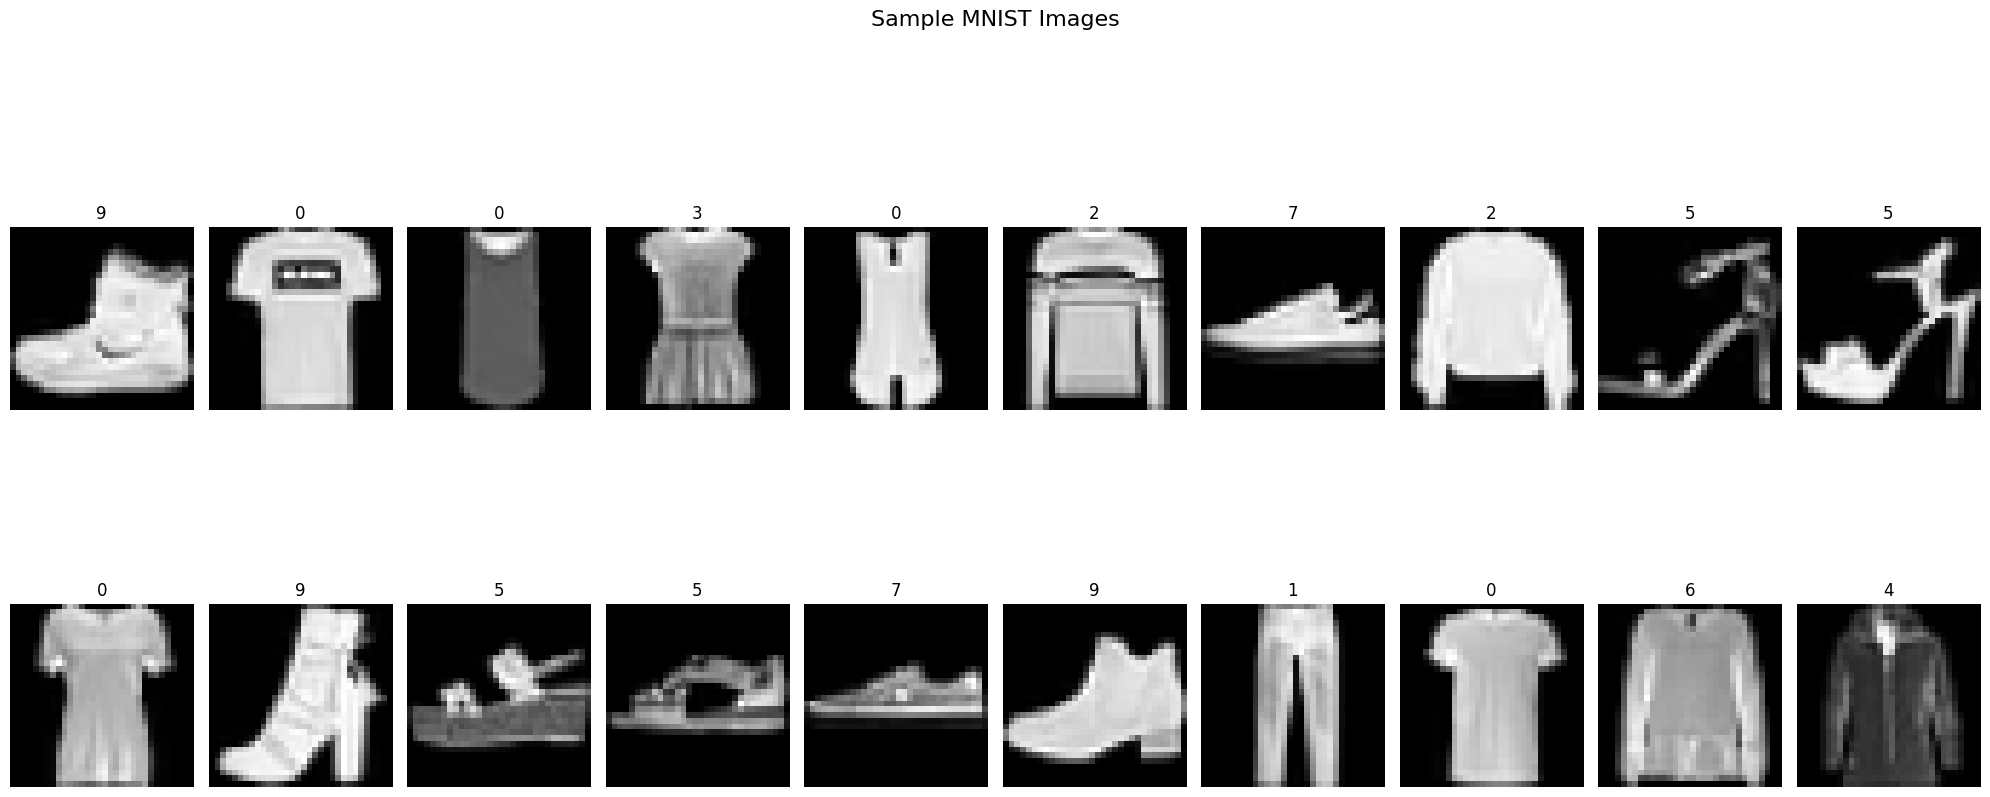

In [35]:
def show_sample(dataset, n=20):
    plt.figure(figsize=(20, 10)) 
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n // 2, i + 1)
        # .squeeze() removes the channel dimension (1, 28, 28) -> (28, 28)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(label)
        plt.axis('off')
    
    plt.suptitle("Sample MNIST Images", fontsize=16)
    plt.tight_layout()
    plt.show()

show_sample(train_dataset, n=20)

### 5. Exploratory Data Analysis (EDA)

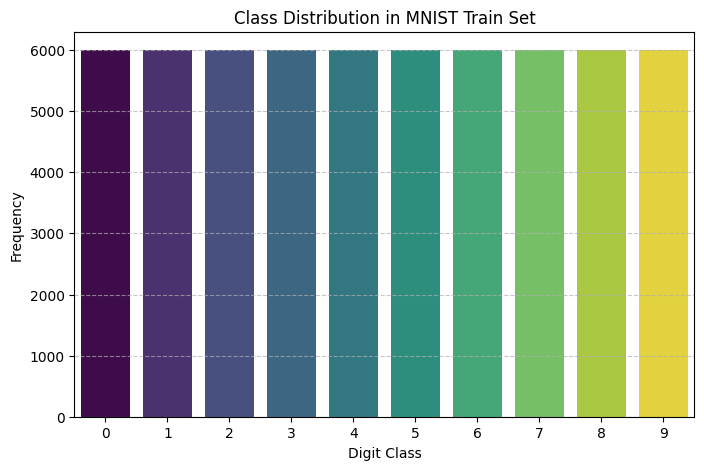

In [47]:
# Extract all labels from the dataset
labels = [label for _, label in train_dataset]

# Create a count plot
plt.figure(figsize=(8, 5))
sns.countplot(x=labels, palette='viridis', hue=labels , legend=False)
plt.title("Class Distribution in MNIST Train Set")
plt.xlabel("Digit Class")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6. Model Architecture and Initialization

In [37]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)

        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))

        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x
model=CNNModel().to(device)

### 7. Loss Function and Optimizer

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

### 8. Training Loop Implementation

In [39]:
train_losses = []

best_loss = float("inf")

model.train()  # Set model to training mode

for epoch in range(EPOCHS):

    running_loss = 0.0

    for images, labels in train_loader:

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # 1. Forward Pass
        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        # 2. Backward Pass
        loss.backward()

        # 3. Update weights
        optimizer.step()

        running_loss += loss.item()


    # Average loss for this epoch
    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)


    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss

        torch.save(
            model.state_dict(),
            CHECKPOINT
        )

        print("Best model saved!")
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")
print("Training finished!")

Best model saved!
Epoch [1/8], Loss: 0.5085
Best model saved!
Epoch [2/8], Loss: 0.3383
Best model saved!
Epoch [3/8], Loss: 0.2917
Best model saved!
Epoch [4/8], Loss: 0.2592
Best model saved!
Epoch [5/8], Loss: 0.2336
Best model saved!
Epoch [6/8], Loss: 0.2151
Best model saved!
Epoch [7/8], Loss: 0.2025
Best model saved!
Epoch [8/8], Loss: 0.1885
Training finished!


### 9. Plot Training Loss

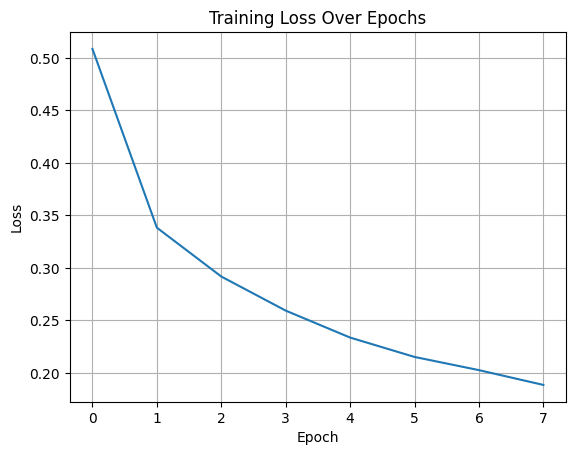

In [40]:
# ... Plot Training Loss ...
plt.plot(train_losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### 10. Evaluation

In [49]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 91.88%


### 11. Confusion Matrix

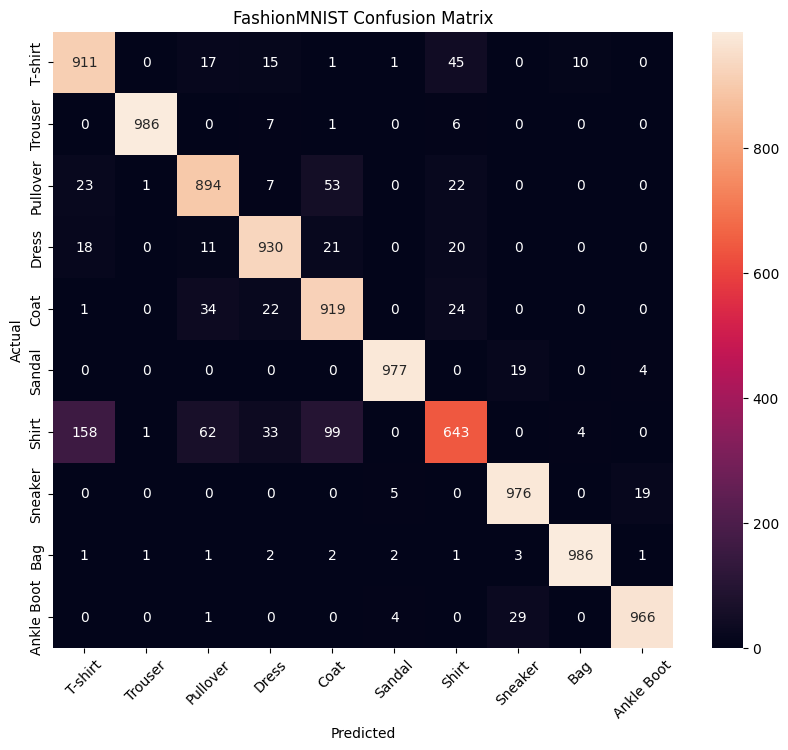

In [52]:
classes = ["T-shirt","Trouser","Pullover","Dress","Coat",
           "Sandal","Shirt","Sneaker","Bag","Ankle Boot"]

conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes)

plt.title("FashionMNIST Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.show()

### 12. Inference on One Image

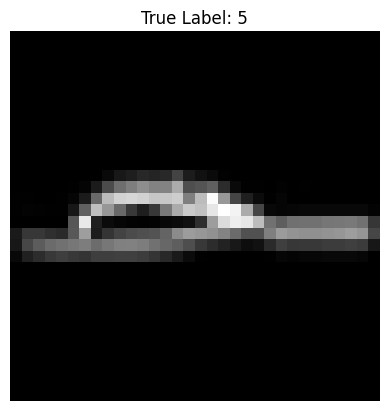

True Label: 5
Predicted Class: 5


In [53]:
# Load the best saved model
model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
model.eval()

# Get one image from the test dataset
sample_img, sample_label = test_dataset[8]

# Display the image
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {sample_label}")
plt.axis('off')
plt.show()

# Add batch dimension and move to device
sample_tensor = sample_img.unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print(f"True Label: {sample_label}")
print(f"Predicted Class: {predicted_class}")